In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [40]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [42]:
df.shape

(7043, 21)

In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df=df.drop('customerID',axis=1)

In [47]:
df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [48]:
df['Partner']=df['Partner'].map({'Yes':1,'No':0})
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1,'No':0})
df['PhoneService']=df['PhoneService'].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Male':1,'Female':0})

In [49]:
cat_cols=list(df.select_dtypes(include='object').columns)

In [50]:
for col in cat_cols:
  print(f'{col}: {df[col].unique()}')

MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


In [51]:
df['MultipleLines']=df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2})
df['TechSupport']=df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingTV']=df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2})
df['Contract']=df['Contract'].map({'Month-to-month':1,'One year':2,'Two year':3})

In [52]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [53]:
num_cols=list(df.select_dtypes(include='number').columns)
num_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [54]:
encoder = OneHotEncoder(sparse_output=False)

# 2. Fit + transform the categorical column
encoded_array = encoder.fit_transform(df[['PaymentMethod']])

# 3. Convert result back to DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['PaymentMethod'])
)

# 4. Remove original column and add encoded columns
df = pd.concat(
    [df.drop('PaymentMethod', axis=1), encoded_df],
    axis=1
)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   InternetService                          7043 non-null   object 
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

In [56]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65


In [57]:
nums_col_df=df.select_dtypes(include='number')
nums_col_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

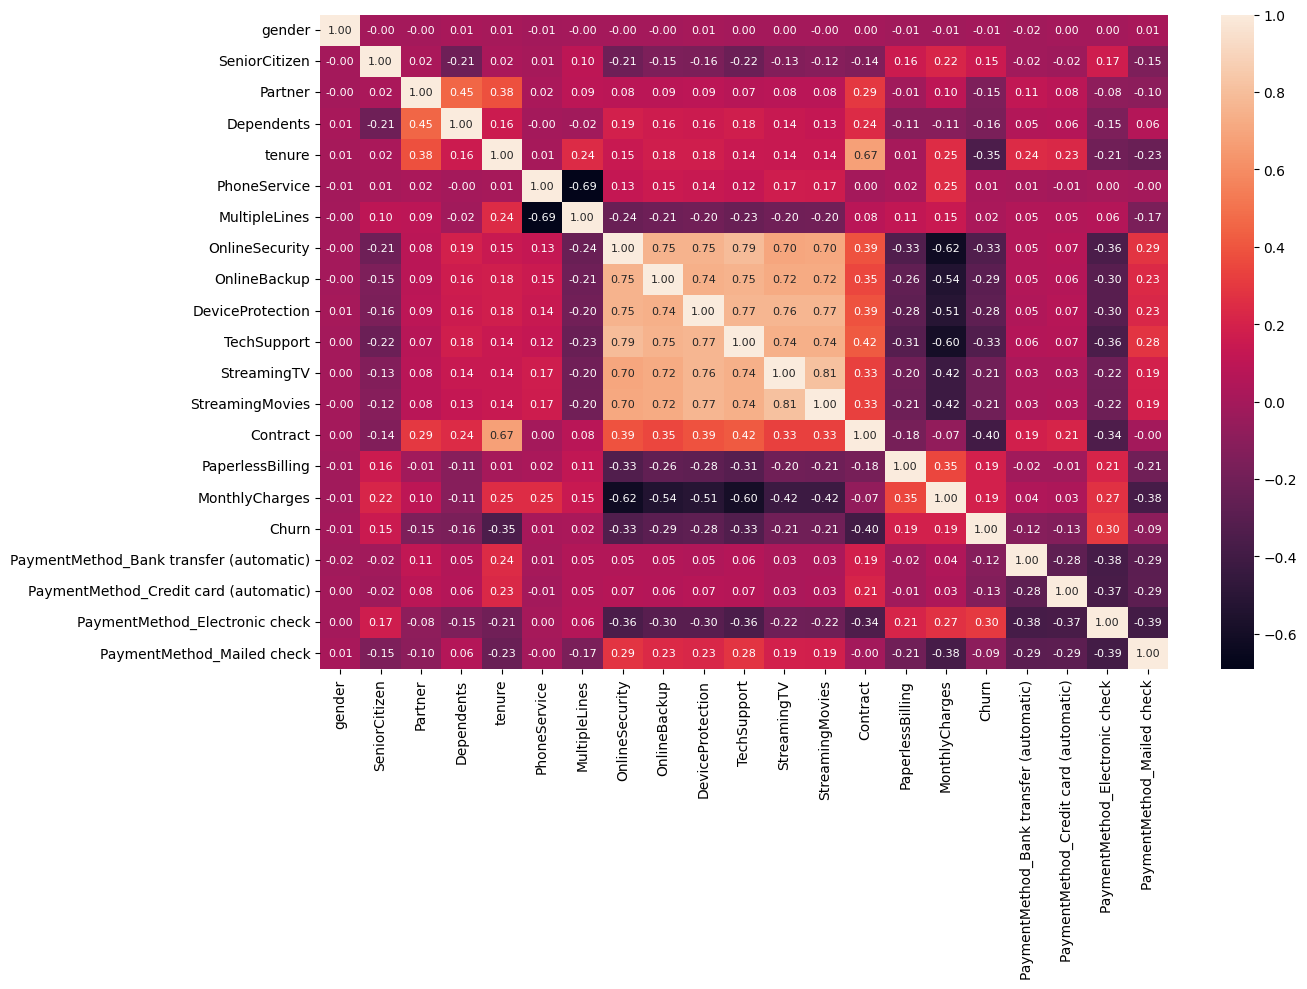

In [112]:
plt.figure(figsize=(14, 10))
sns.heatmap(nums_col_df.corr(), annot=True, fmt='.2f', cmap='rocket',
            annot_kws={"size": 8}, cbar=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

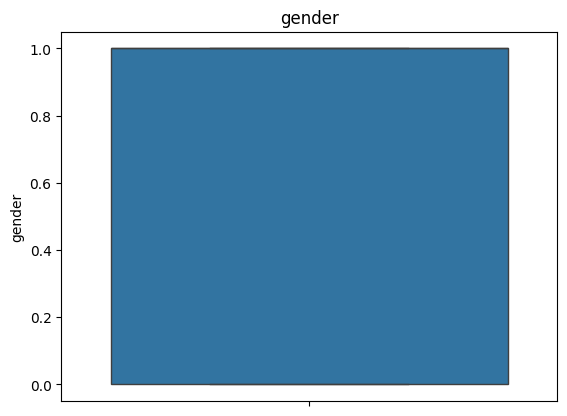

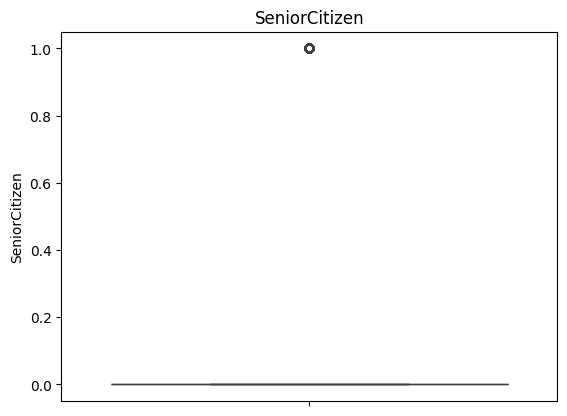

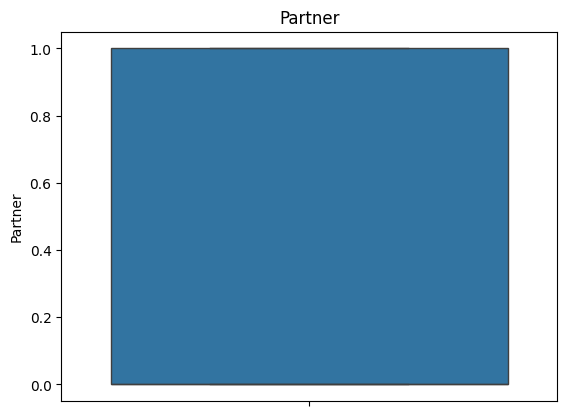

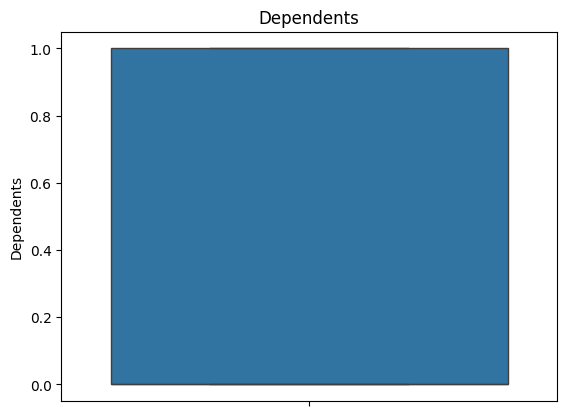

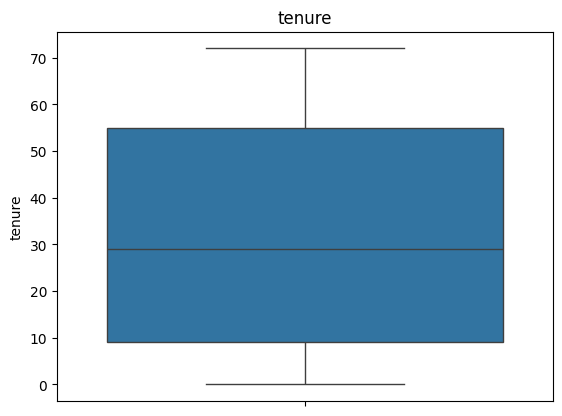

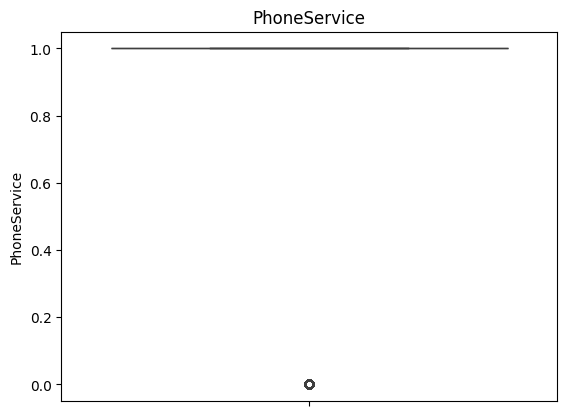

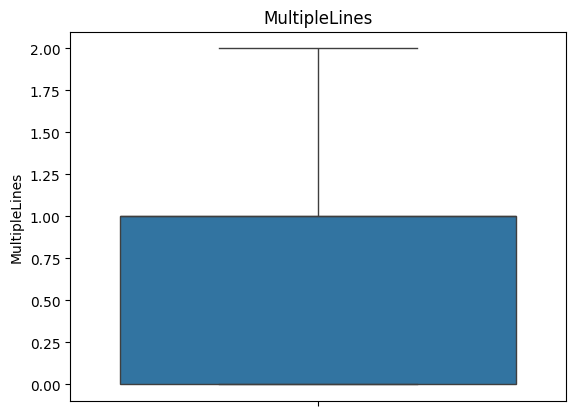

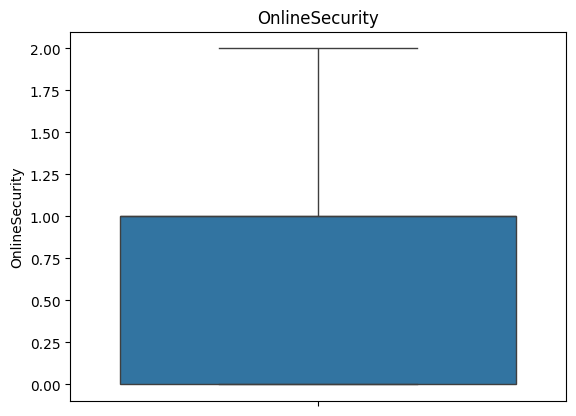

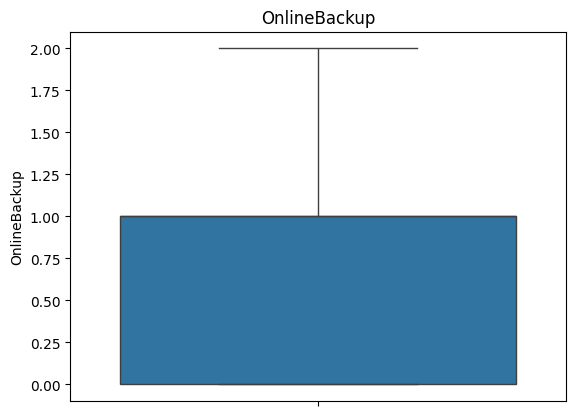

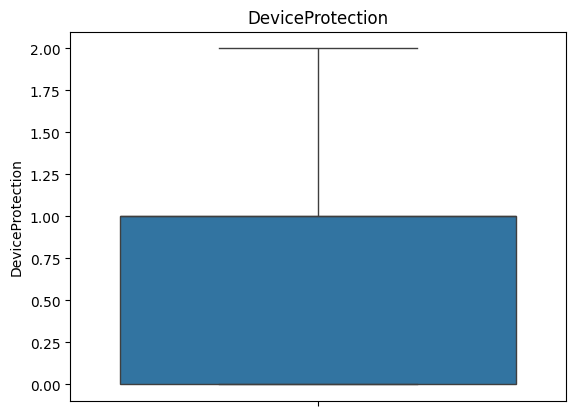

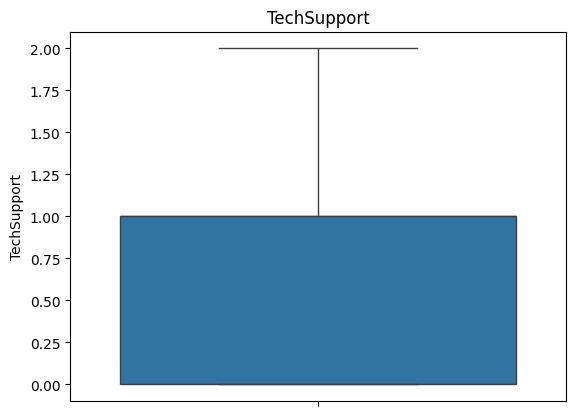

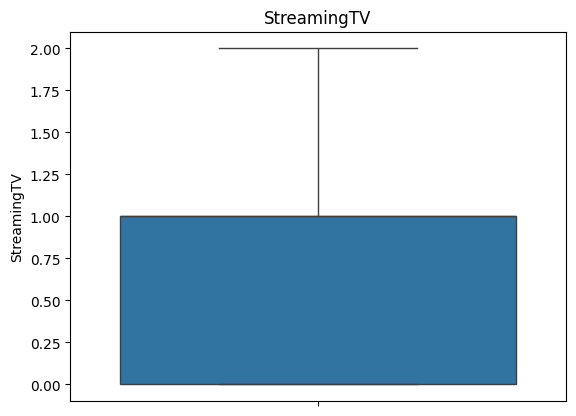

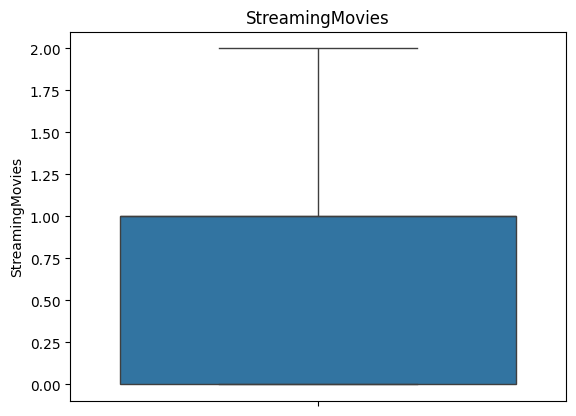

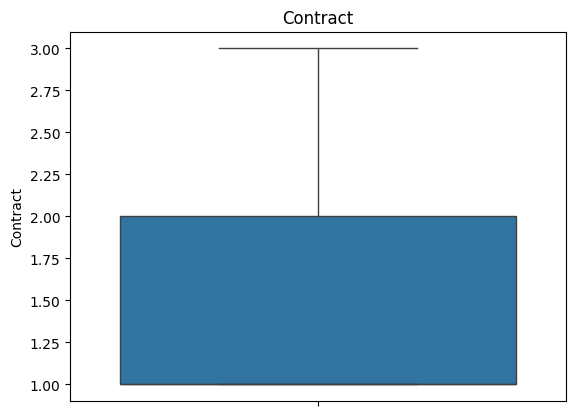

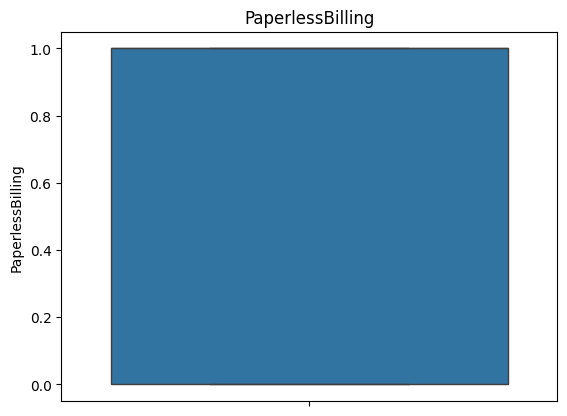

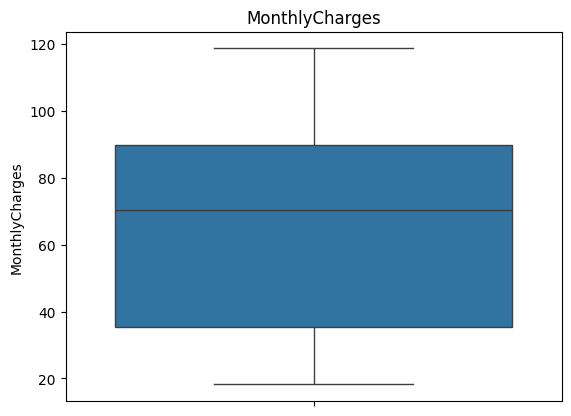

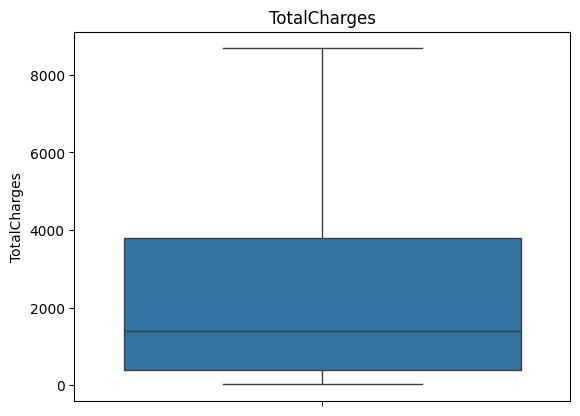

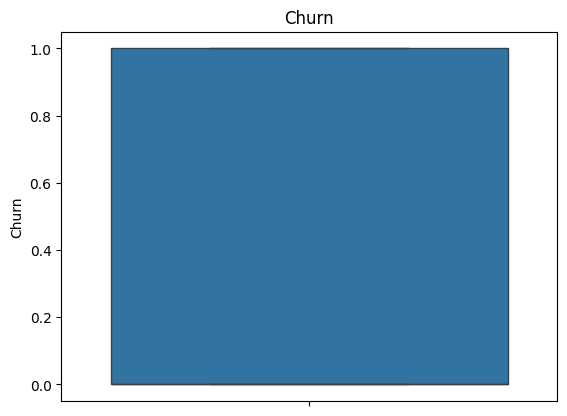

In [59]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [60]:
nums_col_df.loc[df['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
488,0,0,1,1,0,0,2,1,0,1,...,0,3,1,52.55,NaN,0,1.0,0.0,0.0,0.0
753,1,0,0,1,0,1,0,2,2,2,...,2,3,0,20.25,NaN,0,0.0,0.0,0.0,1.0
936,0,0,1,1,0,1,0,1,1,1,...,1,3,0,80.85,NaN,0,0.0,0.0,0.0,1.0
1082,1,0,1,1,0,1,1,2,2,2,...,2,3,0,25.75,NaN,0,0.0,0.0,0.0,1.0
1340,0,0,1,1,0,0,2,1,1,1,...,0,3,0,56.05,NaN,0,0.0,1.0,0.0,0.0
3331,1,0,1,1,0,1,0,2,2,2,...,2,3,0,19.85,NaN,0,0.0,0.0,0.0,1.0
3826,1,0,1,1,0,1,1,2,2,2,...,2,3,0,25.35,NaN,0,0.0,0.0,0.0,1.0
4380,0,0,1,1,0,1,0,2,2,2,...,2,3,0,20.00,NaN,0,0.0,0.0,0.0,1.0
5218,1,0,1,1,0,1,0,2,2,2,...,2,2,1,19.70,NaN,0,0.0,0.0,0.0,1.0
6670,0,0,1,1,0,1,1,0,1,1,...,0,3,0,73.35,NaN,0,0.0,0.0,0.0,1.0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   InternetService                          7043 non-null   object 
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

In [62]:
nums_col_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

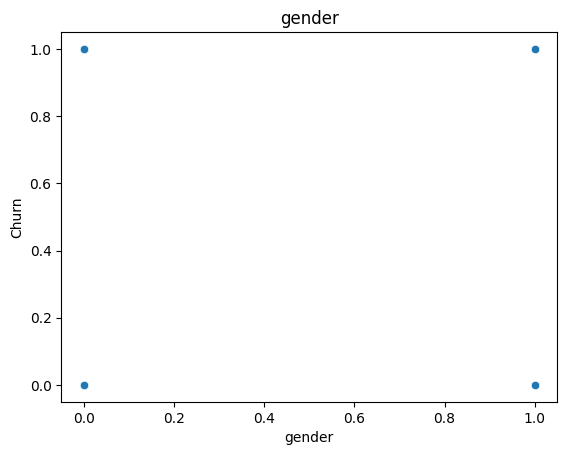

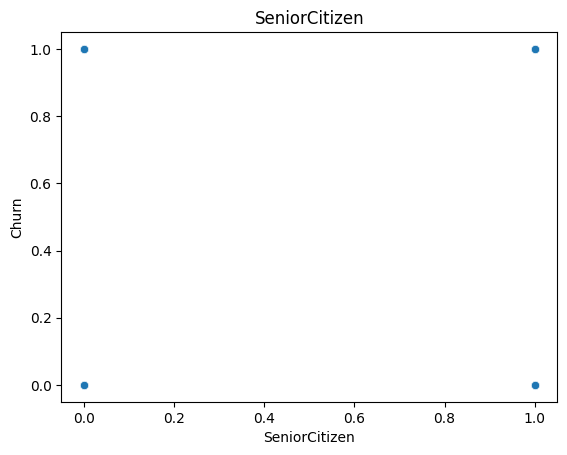

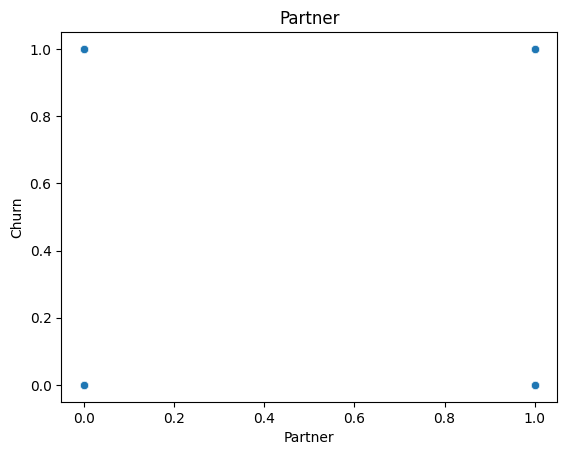

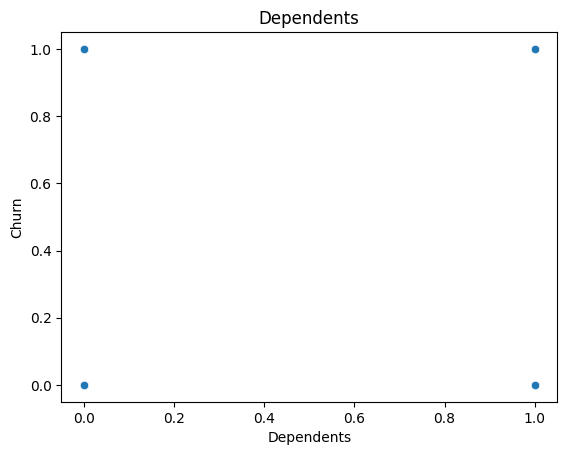

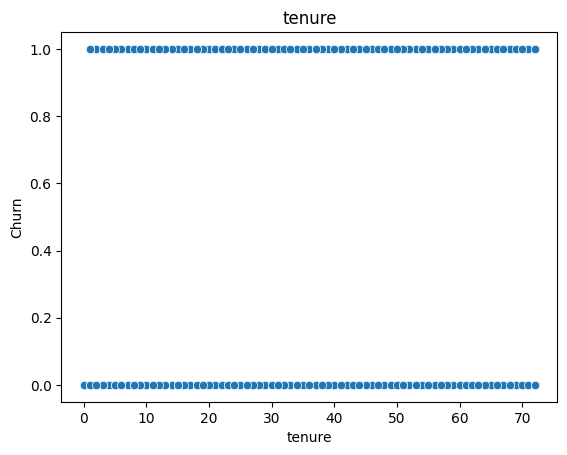

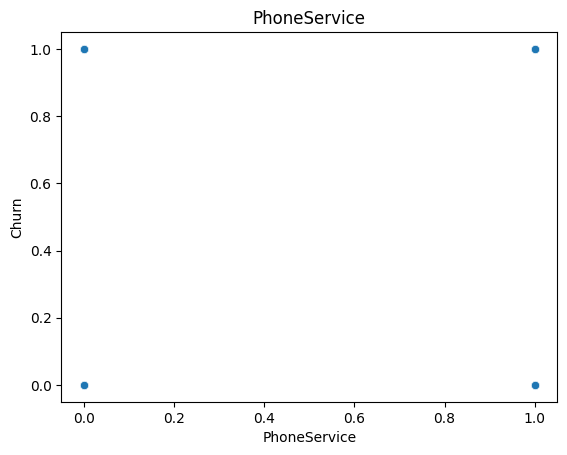

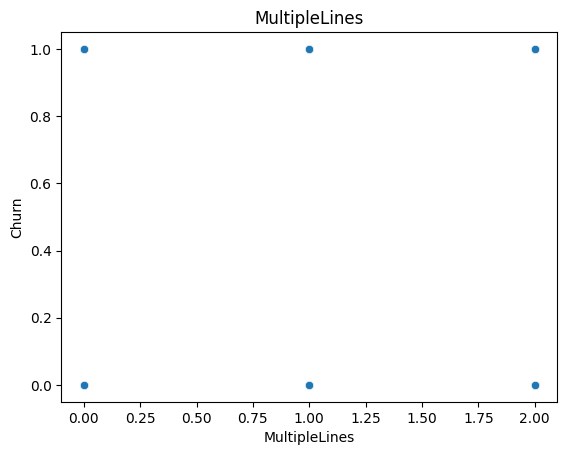

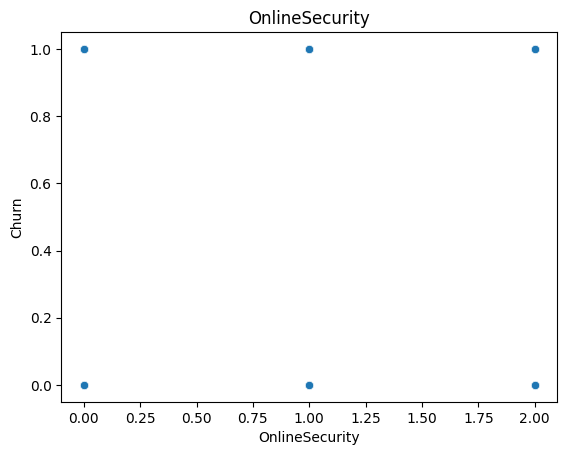

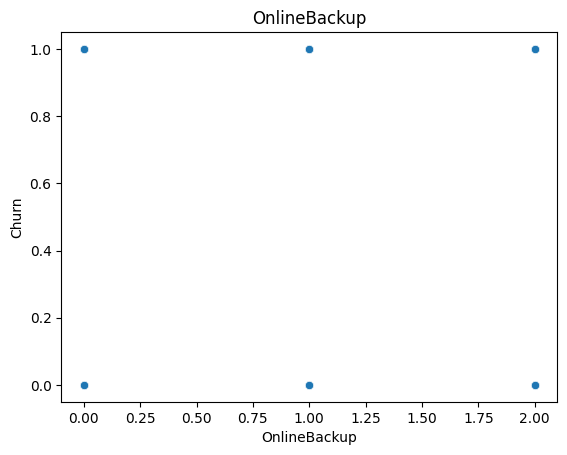

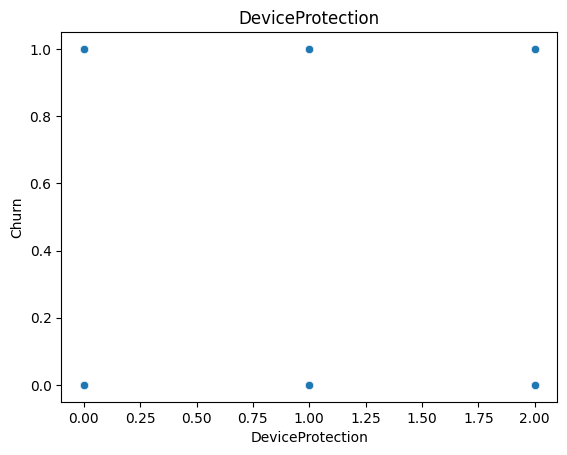

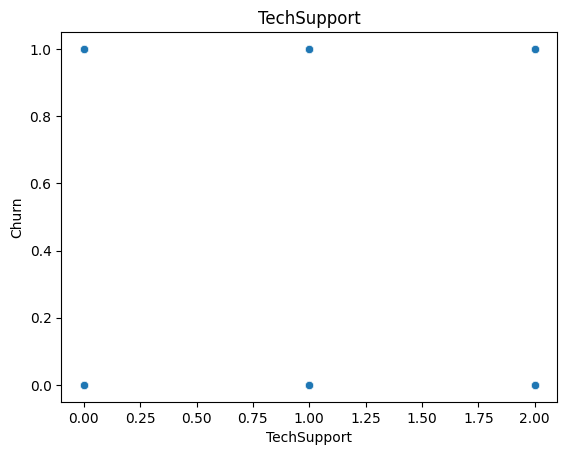

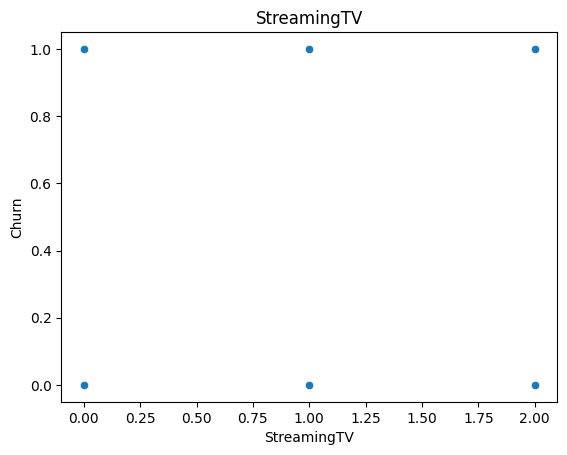

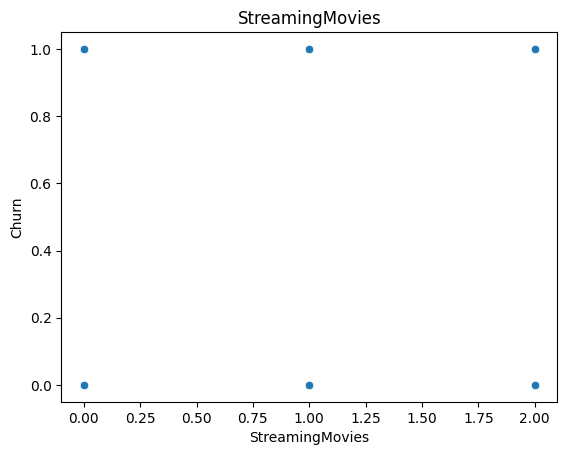

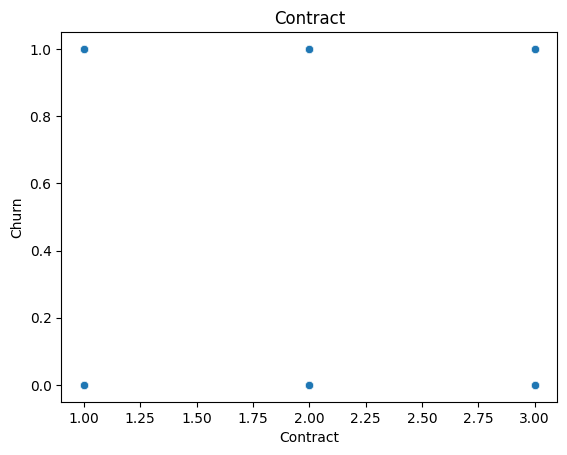

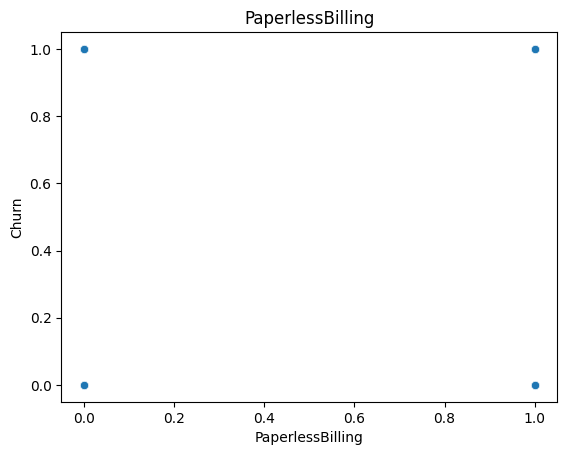

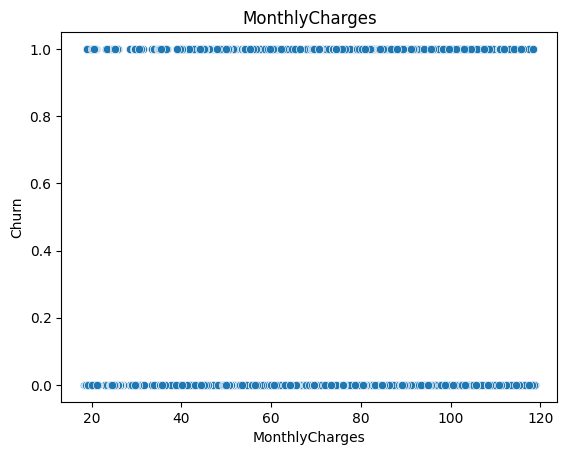

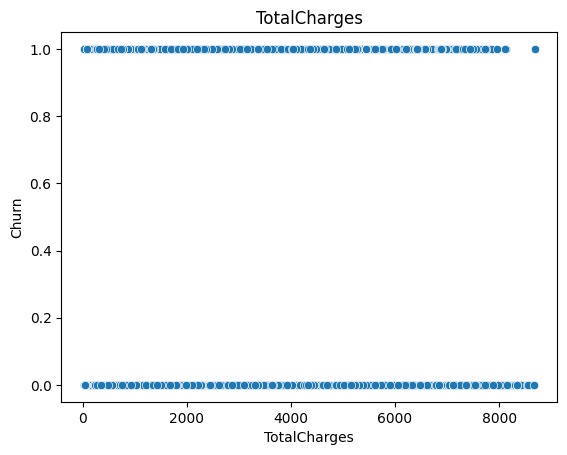

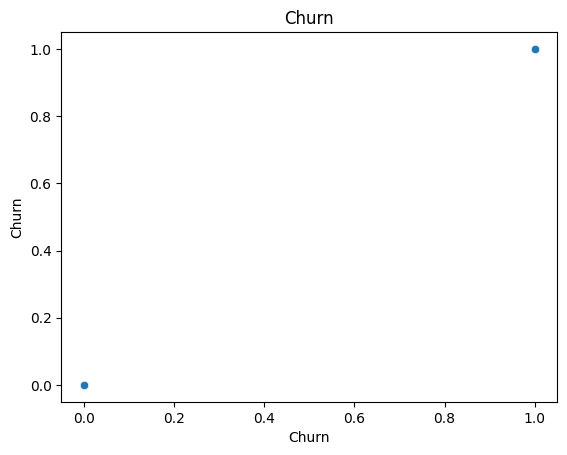

In [63]:
for col in num_cols:
  sns.scatterplot(y=nums_col_df['Churn'],x=nums_col_df[col])
  plt.title(col)
  plt.show()

<Axes: xlabel='tenure', ylabel='Churn'>

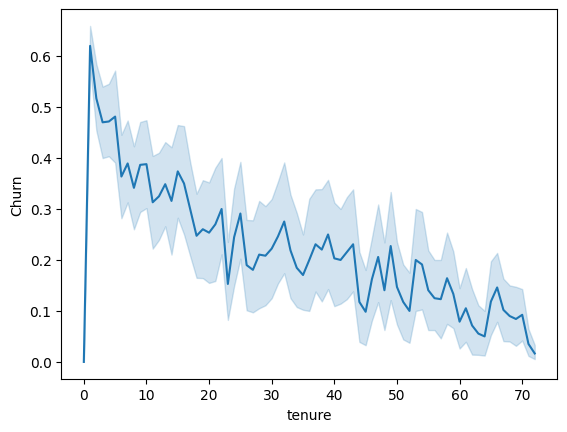

In [64]:
sns.lineplot(
    data=nums_col_df,
    x="tenure",
    y="Churn"
)

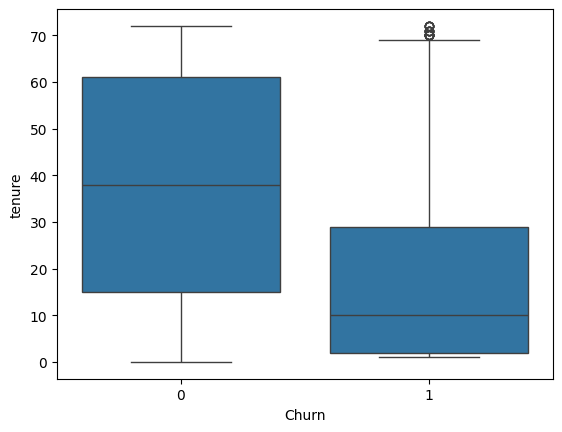

In [65]:
sns.boxplot(data=nums_col_df, x="Churn", y="tenure")
plt.show()

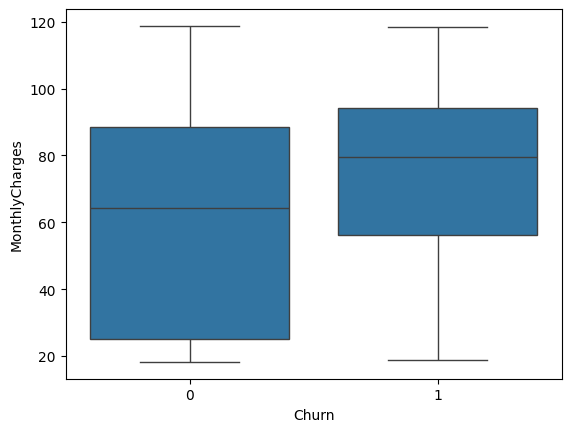

In [66]:
sns.boxplot(data=nums_col_df, x="Churn", y="MonthlyCharges")
plt.show()

In [67]:
nums_col_df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [68]:
nums_col_df.drop(columns=['TotalCharges'], inplace=True)

In [69]:
nums_col_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,2,0,1,0,...,0,0,1,1,29.85,0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,2,0,56.95,0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,1,1,53.85,1,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,2,1,0,1,...,0,0,2,0,42.30,0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,1,70.70,1,0.0,0.0,1.0,0.0


In [70]:
nums_col_df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [120]:
y= nums_col_df['Churn']
# X= nums_col_df.drop('Churn', axis=1)

In [121]:
X = nums_col_df.drop(
    columns=['Churn', 'gender', 'PhoneService']
)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:

from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(y_train.value_counts())

Class distribution before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

Class distribution after SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


In [117]:
models= {'Logistic Regression': LogisticRegression(), 'Naive Bayes': GaussianNB(),'KNN': KNeighborsClassifier(n_neighbors= 10),'Decision Tree': DecisionTreeClassifier(), 'Random Forest': RandomForestClassifier(), 'Adaboost': AdaBoostClassifier()}


In [124]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000, 5000]
    },
    'Naive Bayes': {
        'var_smoothing': np.logspace(0, -9, num=100)
    },
    'KNN': {
        'n_neighbors': list(range(3, 21)),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Adaboost': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    }
}

best_models = {}

for name, model in models.items():
    print(f"Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=20,
        scoring='f1',
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    print(f"Best params: {search.best_params_}")
    print(f"Best CV F1 score: {search.best_score_:.4f}")
    print()

# Replace models with the tuned versions so downstream evaluation cells use them
models = best_models

Tuning Logistic Regression...
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.01}
Best CV F1 score: 0.7817

Tuning Naive Bayes...
Best params: {'var_smoothing': np.float64(1.5199110829529332e-05)}
Best CV F1 score: 0.7793

Tuning KNN...
Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 4}
Best CV F1 score: 0.8477

Tuning Decision Tree...
Best params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'entropy'}
Best CV F1 score: 0.8100

Tuning Random Forest...
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best CV F1 score: 0.8274

Tuning Adaboost...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'n_estimators': 300, 'learning_rate': 1.0}
Best CV F1 score: 0.8174



In [131]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    print(name)
    print("Train Accuracy:", train_accuracy)
    print("Test Accuracy:", test_accuracy)
    print()

Logistic Regression
Train Accuracy: 0.7768245529241179
Test Accuracy: 0.7452093683463449

Naive Bayes
Train Accuracy: 0.7622039632672789
Test Accuracy: 0.709013484740951

KNN
Train Accuracy: 0.9981875302078299
Test Accuracy: 0.7388218594748048

Decision Tree
Train Accuracy: 0.8761478975350411
Test Accuracy: 0.7608232789212207

Random Forest
Train Accuracy: 0.9456259062348961
Test Accuracy: 0.78708303761533

Adaboost
Train Accuracy: 0.8349444175930402
Test Accuracy: 0.7842441447835344



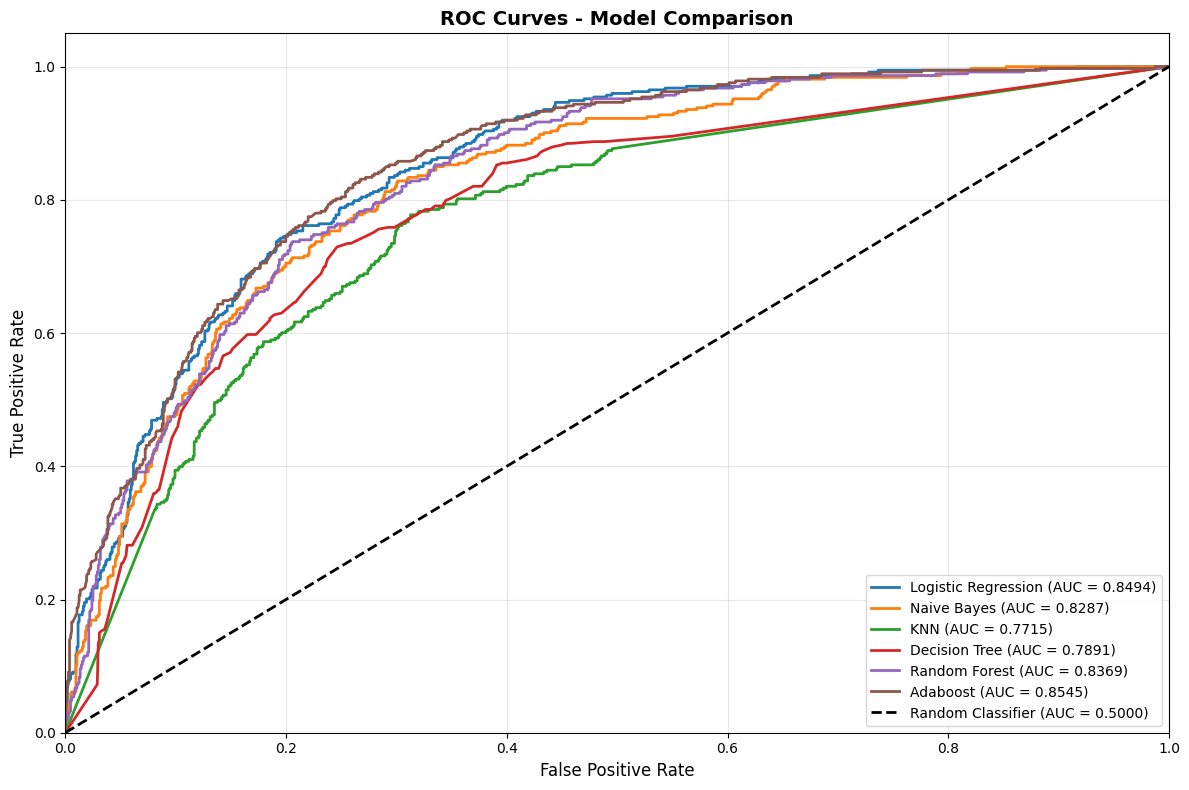


AUC Scores for Each Model
Logistic Regression      : 0.8494
Naive Bayes              : 0.8287
KNN                      : 0.7715
Decision Tree            : 0.7891
Random Forest            : 0.8369
Adaboost                 : 0.8545


In [127]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curves for each model
plt.figure(figsize=(12, 8))

for name, model in models.items():
    # Predictions on test set
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of Class 1 (Churn)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')

# Labels and formatting
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# Print AUC scores in a table
print("\n" + "="*50)
print("AUC Scores for Each Model")
print("="*50)
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"{name:25s}: {auc_score:.4f}")
print("="*50)

In [102]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Precision: 0.6774193548387096
Recall: 0.5630026809651475
F1 Score: 0.6149341142020498

Naive Bayes
Precision: 0.4818181818181818
Recall: 0.8525469168900804
F1 Score: 0.6156824782187803

KNN
Precision: 0.625
Recall: 0.4289544235924933
F1 Score: 0.5087440381558028

Decision Tree
Precision: 0.48360655737704916
Recall: 0.4745308310991957
F1 Score: 0.4790257104194858

Random Forest
Precision: 0.6479400749063671
Recall: 0.46380697050938335
F1 Score: 0.540625

Adaboost
Precision: 0.6573208722741433
Recall: 0.5656836461126006
F1 Score: 0.6080691642651297



In [129]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, average=None)
    recall = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred)

    print(name)
    print("Precision Class 0:", precision[0])
    print("Precision Class 1:", precision[1])
    print("Recall Class 0:", recall[0])
    print("Recall Class 1:", recall[1])
    print("F1 Score:", f1)
    print()

Logistic Regression
Precision Class 0: 0.9133089133089133
Precision Class 1: 0.511864406779661
Recall Class 0: 0.722007722007722
Recall Class 1: 0.8096514745308311
F1 Score: 0.6272066458982347

Naive Bayes
Precision Class 0: 0.9252717391304348
Precision Class 1: 0.4725111441307578
Recall Class 0: 0.6573359073359073
Recall Class 1: 0.8525469168900804
F1 Score: 0.6080305927342257

KNN
Precision Class 0: 0.8553191489361702
Precision Class 1: 0.5053304904051172
Recall Class 0: 0.7760617760617761
Recall Class 1: 0.6353887399463807
F1 Score: 0.5629453681710214

Decision Tree
Precision Class 0: 0.858908341915551
Precision Class 1: 0.5388127853881278
Recall Class 0: 0.805019305019305
Recall Class 1: 0.6327077747989276
F1 Score: 0.5819975339087546

Random Forest
Precision Class 0: 0.857421875
Precision Class 1: 0.5896103896103896
Recall Class 0: 0.8474903474903475
Recall Class 1: 0.6085790884718498
F1 Score: 0.5989445910290238

Adaboost
Precision Class 0: 0.8969631236442517
Precision Class 1: 0

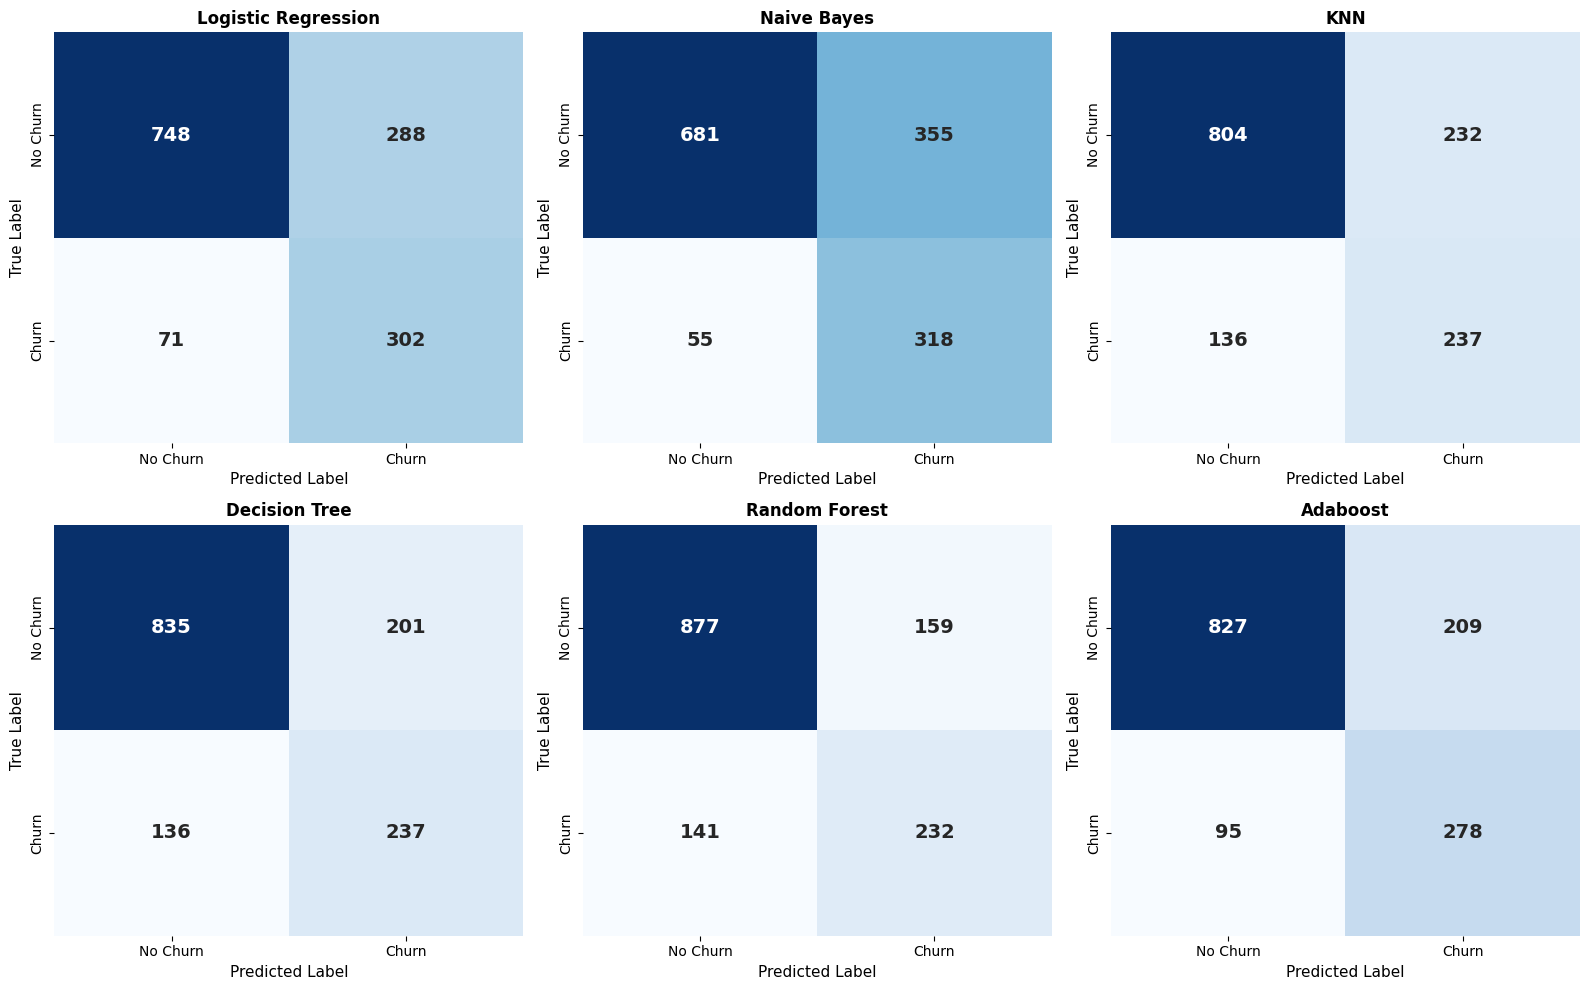


CONFUSION MATRIX BREAKDOWN FOR ALL MODELS

Logistic Regression:
  True Negatives (TN)  :  748  (Correctly predicted No Churn)
  False Positives (FP) :  288  (Incorrectly predicted Churn)
  False Negatives (FN) :   71  (Missed churners - PROBLEM!)
  True Positives (TP)  :  302  (Correctly predicted Churn)

Naive Bayes:
  True Negatives (TN)  :  681  (Correctly predicted No Churn)
  False Positives (FP) :  355  (Incorrectly predicted Churn)
  False Negatives (FN) :   55  (Missed churners - PROBLEM!)
  True Positives (TP)  :  318  (Correctly predicted Churn)

KNN:
  True Negatives (TN)  :  804  (Correctly predicted No Churn)
  False Positives (FP) :  232  (Incorrectly predicted Churn)
  False Negatives (FN) :  136  (Missed churners - PROBLEM!)
  True Positives (TP)  :  237  (Correctly predicted Churn)

Decision Tree:
  True Negatives (TN)  :  835  (Correctly predicted No Churn)
  False Positives (FP) :  201  (Incorrectly predicted Churn)
  False Negatives (FN) :  136  (Missed churners - 

In [132]:
from sklearn.metrics import confusion_matrix

# Create a figure with subplots (2 rows x 3 columns for 6 models)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, (name, model) in enumerate(models.items()):
    # Get predictions
    y_pred = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# Print detailed confusion matrix breakdown
print("\n" + "="*80)
print("CONFUSION MATRIX BREAKDOWN FOR ALL MODELS")
print("="*80)

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}:")
    print(f"  True Negatives (TN)  : {tn:4d}  (Correctly predicted No Churn)")
    print(f"  False Positives (FP) : {fp:4d}  (Incorrectly predicted Churn)")
    print(f"  False Negatives (FN) : {fn:4d}  (Missed churners - PROBLEM!)")
    print(f"  True Positives (TP)  : {tp:4d}  (Correctly predicted Churn)")